**NOTICE:**  
The U.S. Army Corps of Engineers, Risk Management Center (USACE-RMC) makes no guarantees about the results, or appropriateness of outputs, obtained from Numerics.

# 07. Statistical Analysis in Numerics
This notebook covers statistical methods and hypothesis testing.

## What You'll Learn

- Descriptive statistics
- Correlation analysis (Pearson, Spearman, Kendall)
- Hypothesis testing (t-test, Mann-Whitney, Kolmogorov-Smirnov)
- Bootstrap resampling
- Outlier detection (Multiple Grubbs-Beck)
- Data transformations (Box-Cox, Yeo-Johnson)
- Histogram and kernel density estimation

## Real-World Applications

Statistical analysis for data exploration, quality control, and inference.

## Set Up

In [1]:
import pythonnet
pythonnet.load("coreclr")

import clr
from pathlib import Path
from scipy import stats
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random

# Load Numerics DLL
dll_path = Path(r"C:\GIT\Numerics\Numerics\bin\Debug\net8.0\Numerics.dll")
clr.AddReference(str(dll_path))

from Numerics.Data.Statistics import Statistics, Correlation, HypothesisTests, GoodnessOfFit, MultipleGrubbsBeckTest, BoxCox, YeoJohnson
from Numerics.Distributions import Normal, LogNormal, Uniform, GammaDistribution, Exponential, BootstrapAnalysis, ParameterEstimationMethod
from Numerics.Data.Statistics import Statistics
from Numerics.MachineLearning import JenksNaturalBreaks
from Numerics.Mathematics.LinearAlgebra import Matrix, SingularValueDecomposition
from helper_functions import convert_to_dotnet_array

from System import Array

print("✓ Setup complete")

✓ Setup complete


## 1. Descriptive Statistics

Let's analyze streamflow data.

Summary statistics


,Statistic,Value
0,Mean,1.397387e+07
1,Std Dev,4.195469e+07
2,Variance,1.760196e+15
3,Minimum,7.526316e+03
4,Maximum,5.909717e+08
5,Skewness,8.697790e+00
6,Kurtosis,1.038059e+02
7,5th %ile,1.270829e+05
8,25th %ile,8.245169e+05
9,75th %ile,8.827698e+06


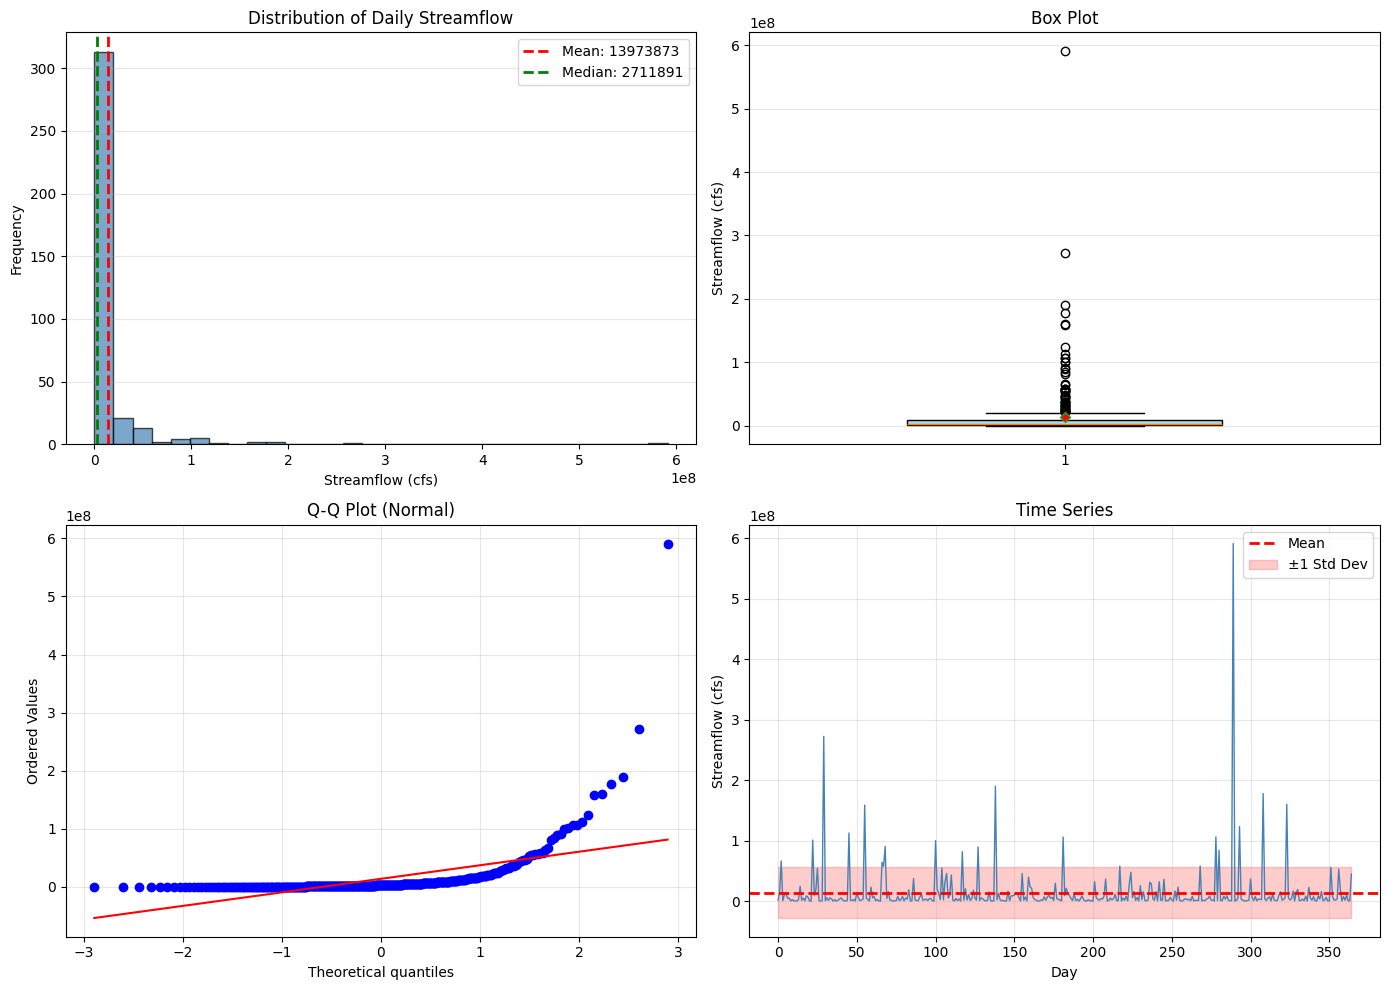

In [2]:
# Generate sample streamflow data (cubic feet per second)
np.random.seed(42)
streamflow = np.array(list(LogNormal(6.5, 0.8).GenerateRandomValues(365, 42)))
streamflow_net = convert_to_dotnet_array(streamflow)

# Pull basic statistics
summary_df = pd.DataFrame({'Statistic':['Mean','Std Dev','Variance','Minimum','Maximum','Skewness','Kurtosis','5th %ile','25th %ile','75th %ile','95th %ile'],'Value':
                           [Statistics.Mean(streamflow_net),Statistics.StandardDeviation(streamflow_net),Statistics.Variance(streamflow_net),Statistics.Minimum(streamflow_net),Statistics.Maximum(streamflow_net),Statistics.Skewness(streamflow_net),Statistics.Kurtosis(streamflow_net),Statistics.Percentile(streamflow_net,0.05),Statistics.Percentile(streamflow_net,0.25),Statistics.Percentile(streamflow_net,0.75),Statistics.Percentile(streamflow_net,0.95)]})
print('Summary statistics')
display(summary_df)

# Plot frequency
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes[0, 0].hist(streamflow, bins=30, alpha=0.7, color='steelblue', edgecolor='black')
# Find mean and median
axes[0, 0].axvline(np.mean(streamflow), color='red', linestyle='--', linewidth=2, label=f'Mean: {np.mean(streamflow):.0f}')
axes[0, 0].axvline(np.median(streamflow), color='green', linestyle='--', linewidth=2, label=f'Median: {np.median(streamflow):.0f}')
axes[0, 0].set_xlabel('Streamflow (cfs)'); axes[0, 0].set_ylabel('Frequency'); axes[0, 0].set_title('Distribution of Daily Streamflow'); axes[0, 0].legend(); axes[0, 0].grid(True, alpha=0.3, axis='y')

# Plot boxplots
bp = axes[0, 1].boxplot([streamflow], vert=True, patch_artist=True, widths=0.5, showmeans=True, meanprops=dict(marker='D', markerfacecolor='red', markersize=5))
bp['boxes'][0].set_facecolor('lightblue')
axes[0, 1].set_ylabel('Streamflow (cfs)'); axes[0, 1].set_title('Box Plot'); axes[0, 1].grid(True, alpha=0.3, axis='y')

# Plot QQ-plot
stats.probplot(streamflow, dist='norm', plot=axes[1, 0]); axes[1, 0].set_title('Q-Q Plot (Normal)'); axes[1, 0].grid(True, alpha=0.3)

# Plot timeseries data
axes[1, 1].plot(range(len(streamflow)), streamflow, linewidth=1, color='steelblue')
# Plot mean
axes[1, 1].axhline(np.mean(streamflow), color='red', linestyle='--', linewidth=2, label='Mean')
# Plot confidence interval
axes[1, 1].fill_between(range(len(streamflow)), np.mean(streamflow)-np.std(streamflow), np.mean(streamflow)+np.std(streamflow), alpha=0.2, color='red', label='±1 Std Dev')
axes[1, 1].set_xlabel('Day'); axes[1, 1].set_ylabel('Streamflow (cfs)'); axes[1, 1].set_title('Time Series'); axes[1, 1].legend(); axes[1, 1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## 2. Correlation Analysis

Measure relationships between variables.

Three common coefficients:
- Pearson: linear association (sensitive to outliers).
- Spearman: rank-based monotonic association (nonparametric).
- Kendall: rank concordance, robust for smaller samples.


Correlation Analysis:
Pearson correlation:   1.0000  (linear relationship)
Spearman correlation:  1.0000  (monotonic relationship)
Kendall's tau:         1.0000  (rank correlation)


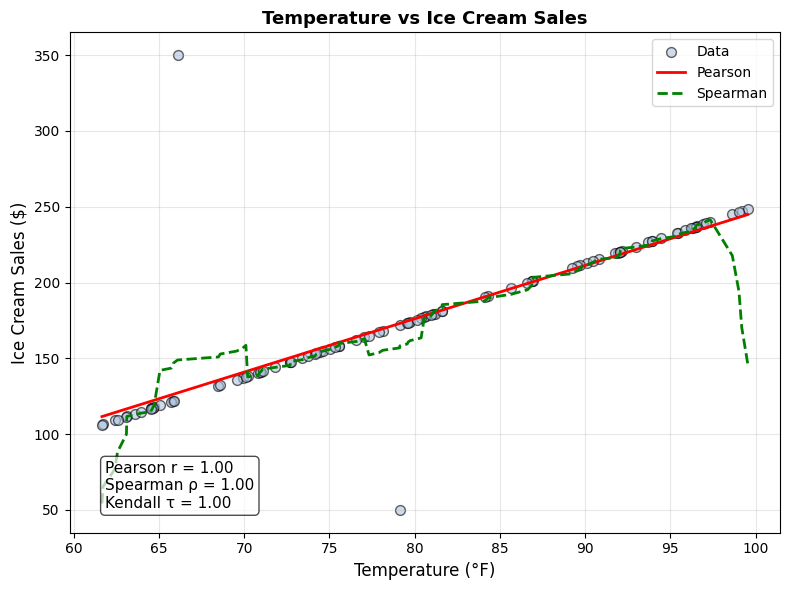

In [3]:
# Generate correlated data: temperature vs ice cream sales
np.random.seed(123)
n = 100
temperature = Uniform(60,100).GenerateRandomValues(n,321)
temp_py = np.array(temperature)
noise = Uniform(0, 50).GenerateRandomValues(n,321)
ice_cream_sales = 2.5 * temp_py - 50 + np.array(noise)

# Convert to .NET for Numerics
sales_net = convert_to_dotnet_array(ice_cream_sales)

# Add some outliers
ice_cream_sales[5] = 50
ice_cream_sales[50] = 350

# Pearson correlation (linear)
pearson_corr = Correlation.Pearson(temperature, sales_net)

# Spearman correlation (rank-based)
spearman_corr = Correlation.Spearman(temperature, sales_net)

# Kendall Tau correlation (ordinal)
kendall_corr = Correlation.KendallsTau(temperature, sales_net)

print("\nCorrelation Analysis:")
print(f"Pearson correlation:   {pearson_corr:.4f}  (linear relationship)")
print(f"Spearman correlation:  {spearman_corr:.4f}  (monotonic relationship)")
print(f"Kendall's tau:         {kendall_corr:.4f}  (rank correlation)")

# Visualize correlations
plt.figure(figsize=(8, 6))

plt.text(0.05, 0.05,
         f"Pearson r = {pearson_corr:.2f}\n"
         f"Spearman ρ = {spearman_corr:.2f}\n"
         f"Kendall τ = {kendall_corr:.2f}", # Kendall: annotate as a label only (same monotonic info as Spearman)
         transform=plt.gca().transAxes,
         fontsize=11,
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))


# Scatter
plt.scatter(temp_py, ice_cream_sales, alpha=0.6, s=50,
            color='lightsteelblue', edgecolor='black', label='Data')

# 1) Pearson: linear fit
z = np.polyfit(temp_py, ice_cream_sales, 1)
p = np.poly1d(z)
x_line = np.linspace(temp_py.min(), temp_py.max(), 200)
plt.plot(x_line, p(x_line), 'r-', linewidth=2,
         label=f'Pearson')

# 2) Spearman: monotonic smooth curve (fit in rank space, plot in x-space)
order = np.argsort(temp_py)     # Sort by temperature
temp_sorted = temp_py[order]
sales_sorted = ice_cream_sales[order]

# Smooth with a lowess/rolling mean style approximation (no extra libs)
window = max(5, len(temp_sorted)//10)
smoothed = np.convolve(sales_sorted, np.ones(window)/window, mode='same')
plt.plot(temp_sorted, smoothed, color='green', linewidth=2,
         linestyle='--', label=f"Spearman")

plt.xlabel('Temperature (°F)', fontsize=12)
plt.ylabel('Ice Cream Sales ($)', fontsize=12)
plt.title('Temperature vs Ice Cream Sales', fontsize=13, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



## 3. Hypothesis Testing: t-test

Compare means of two groups under approximate normality assumptions.

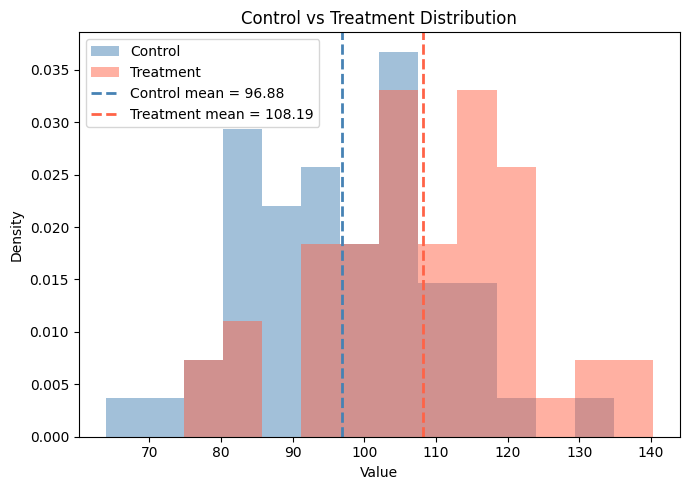

Two-sample t-test summary


,Metric,Value
0,Control mean,96.881317
1,Treatment mean,108.185231
2,P-value,0.000092
3,Conclusion (α=0.05),Reject H0 (significant difference)


In [4]:
# Two treatment groups
np.random.seed(456)
control = Normal(100,15).GenerateRandomValues(50,456)
treatment = Normal(110,15).GenerateRandomValues(50,789)
control_py = np.asarray(control)
treatment_py = np.asarray(treatment)

# Graph treatment groups
plt.figure(figsize=(7, 5))

bins = np.linspace(min(control_py.min(), treatment_py.min()),
                   max(control_py.max(), treatment_py.max()), 15)

plt.hist(control_py, bins=bins, alpha=0.5, density=True, color="steelblue", label="Control")
plt.hist(treatment_py, bins=bins, alpha=0.5, density=True, color="tomato", label="Treatment")
# Graph means
plt.axvline(control_py.mean(), color="steelblue", linestyle="--", linewidth=2,
            label=f"Control mean = {control_py.mean():.2f}")
plt.axvline(treatment_py.mean(), color="tomato", linestyle="--", linewidth=2,
            label=f"Treatment mean = {treatment_py.mean():.2f}")

plt.title("Control vs Treatment Distribution")
plt.xlabel("Value")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()

# Conduct an equal variance test
pval = HypothesisTests.EqualVarianceTtest(control, treatment)
conclusion = 'Reject H0 (significant difference)' if pval < 0.05 else 'Fail to reject H0'

ttest_df = pd.DataFrame({'Metric':['Control mean','Treatment mean','P-value','Conclusion (α=0.05)'],'Value':
                         [np.mean(control_py),np.mean(treatment_py),pval,conclusion]})
print('Two-sample t-test summary')
display(ttest_df)

## 4. Non-Parametric Test: Mann-Whitney U
Use when data are non-normal or when rank-based comparison is preferred.

Mann-Whitney U test summary


,Metric,Value
0,Group A median,16.030177
1,Group B median,16.030177
2,P-value,0.355611
3,Conclusion (α=0.05),No significant distribution difference


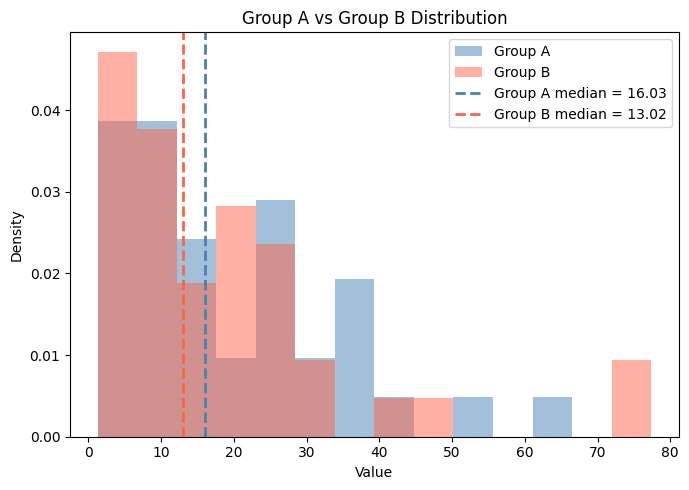

In [5]:
# Non-normal data (skewed)
np.random.seed(789)
group_a = Exponential(1, 25).GenerateRandomValues(40, 789)
group_b = Exponential(1, 20). GenerateRandomValues(40,789)

# Convert to Python lists for simplicity
group_a_py = np.array(group_a)
group_b_py = np.array(group_b)

pval = HypothesisTests.MannWhitneyTest(group_a, group_b)
conclusion = 'Significant distribution difference' if pval < 0.05 else 'No significant distribution difference'

mw_df = pd.DataFrame({'Metric':['Group A median','Group B median','P-value','Conclusion (α=0.05)'],'Value':
                      [np.median(group_a_py),np.median(group_a_py),pval,conclusion]})
print('Mann-Whitney U test summary')
display(mw_df)

# Graph treatment groups
plt.figure(figsize=(7, 5))

bins = np.linspace(min(group_a_py.min(), group_a_py.min()),
                   max(group_b_py.max(), group_b_py.max()), 15)

plt.hist(group_a_py, bins=bins, alpha=0.5, density=True, color="steelblue", label="Group A")
plt.hist(group_b_py, bins=bins, alpha=0.5, density=True, color="tomato", label="Group B")
# Graph means
plt.axvline(np.median(group_a_py), color="steelblue", linestyle="--", linewidth=2,
            label=f"Group A median = {np.median(group_a_py):.2f}")
plt.axvline(np.median(group_b_py), color="tomato", linestyle="--", linewidth=2,
            label=f"Group B median = {np.median(group_b_py):.2f}")

plt.title("Group A vs Group B Distribution")
plt.xlabel("Value")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()

## 5. Goodness-of-Fit: Kolmogorov-Smirnov Test
Test whether observed data are consistent with a specified continuous distribution.

In [6]:
# Numerics does not currently provide a direct method for KS p-value calculation, so we implement it here based on the asymptotic formula.
# The test statistic is compared to the Kolmogrov distribution
def ks_pvalue_one_sample(d, n, tol=1e-8, k_max=1000):
    """
    Two-sided one-sample KS p-value for statistic d and sample size n.
    """
    if n <= 0:
        raise ValueError("n must be positive")

    # Transformation for better approximation
    lam = (np.sqrt(n) + 0.12 + 0.11/np.sqrt(n)) * d

    # Series expansion
    s = 0.0
    for k in range(1, k_max+1):
        term = (-1)**(k-1) * np.exp(-2 * (k**2) * (lam**2))
        s += term
        if abs(term) < tol:
            break
    p = 2 * s
    # Numerical safety
    p = min(max(p, 0.0), 1.0)
    return p

Kolmogorov-Smirnov goodness-of-fit summary


,Metric,Value
0,Sample mean,51.544355
1,Sample std,76.611037
2,KS statistic,1.0
3,P-value,0.0
4,Conclusion (α=0.05),"Data inconsistent with Normal(50,10)"


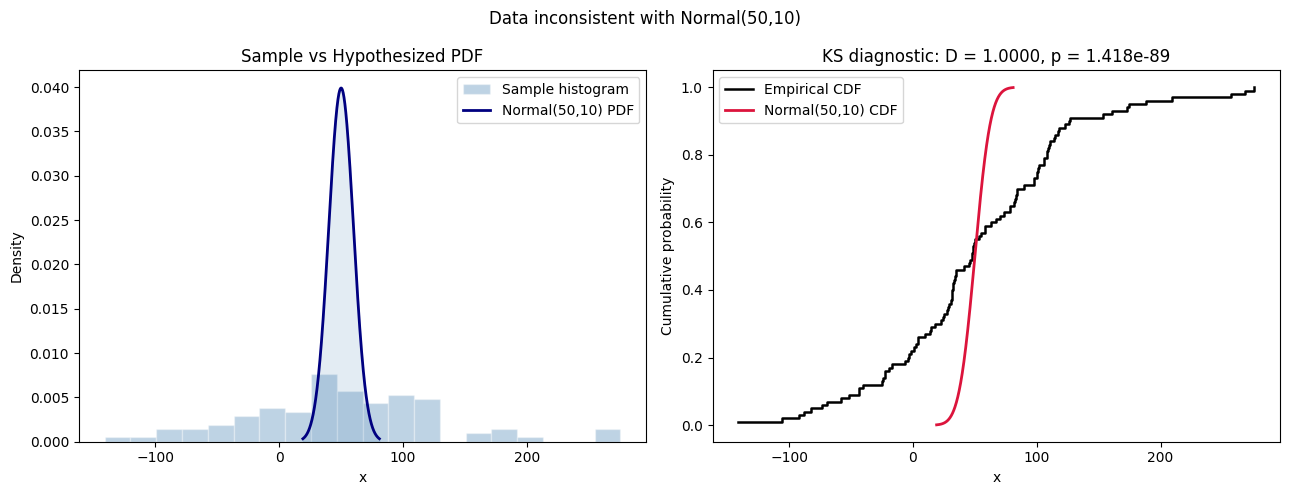

In [7]:
# Generate data
np.random.seed(101)
sample_data = Normal(50,100).GenerateRandomValues(100, 123)
sample_py = np.array(sample_data)

hypothesized_dist = Normal(50, 10)
# This returns the KS test statistic - smaller D indiciates a better fit
ks_test = GoodnessOfFit.KolmogorovSmirnov(sample_data, hypothesized_dist)
pval = ks_pvalue_one_sample(ks_test, len(sample_py))
conclusion = 'Data inconsistent with Normal(50,10)' if pval < 0.05 else 'Data consistent with Normal(50,10)'

ks_df = pd.DataFrame({'Metric':['Sample mean','Sample std','KS statistic','P-value','Conclusion (α=0.05)'],'Value':
                      [np.mean(sample_py),np.std(sample_py, ddof=1),ks_test,pval,conclusion]})
print('Kolmogorov-Smirnov goodness-of-fit summary')
display(ks_df)

# Range for smooth theoretical curve
x_min = hypothesized_dist.InverseCDF(0.001)
x_max = hypothesized_dist.InverseCDF(0.999)
x = np.linspace(x_min, x_max, 500)
pdf = np.array([hypothesized_dist.PDF(xi) for xi in x])
cdf = np.array([hypothesized_dist.CDF(xi) for xi in x])

# Empirical CDF (for KS visualization)
x_ecdf = np.sort(sample_py)
y_ecdf = np.arange(1, len(x_ecdf) + 1) / len(x_ecdf)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# (A) Histogram + theoretical PDF
ax1.hist(sample_py, bins=20, density=True, alpha=0.35, color="steelblue", edgecolor="white", label="Sample histogram")
ax1.plot(x, pdf, color="navy", linewidth=2, label="Normal(50,10) PDF")
ax1.fill_between(x, pdf, alpha=0.15, color="steelblue")
ax1.set_title("Sample vs Hypothesized PDF")
ax1.set_xlabel("x")
ax1.set_ylabel("Density")
ax1.legend()

# (B) ECDF + theoretical CDF
ax2.step(x_ecdf, y_ecdf, where="post", color="black", linewidth=1.8, label="Empirical CDF")
ax2.plot(x, cdf, color="crimson", linewidth=2, label="Normal(50,10) CDF")
ax2.set_title(f"KS diagnostic: D = {ks_test:.4f}, p = {pval:.4g}")
ax2.set_xlabel("x")
ax2.set_ylabel("Cumulative probability")
ax2.legend()

fig.suptitle(conclusion)
fig.tight_layout()
plt.show()

## 6. Bootstrap Resampling

Estimate sampling distribution without parametric assumptions.

The Numerics Bootstrap class requires three delegate functions:
1. **ResampleFunction**: How to resample the data
2. **FitFunction**: How to fit the model to resampled data
3. **StatisticFunction**: What statistics to extract from the fit

Bootstrap summary (5000 replicates)


,Statistic,Sample Estimate,Bootstrap Mean,95% CI Lower,95% CI Upper
0,Mean,38.029598,38.008305,35.884172,40.192871
1,Std Dev,7.705654,7.679659,6.142332,9.363730


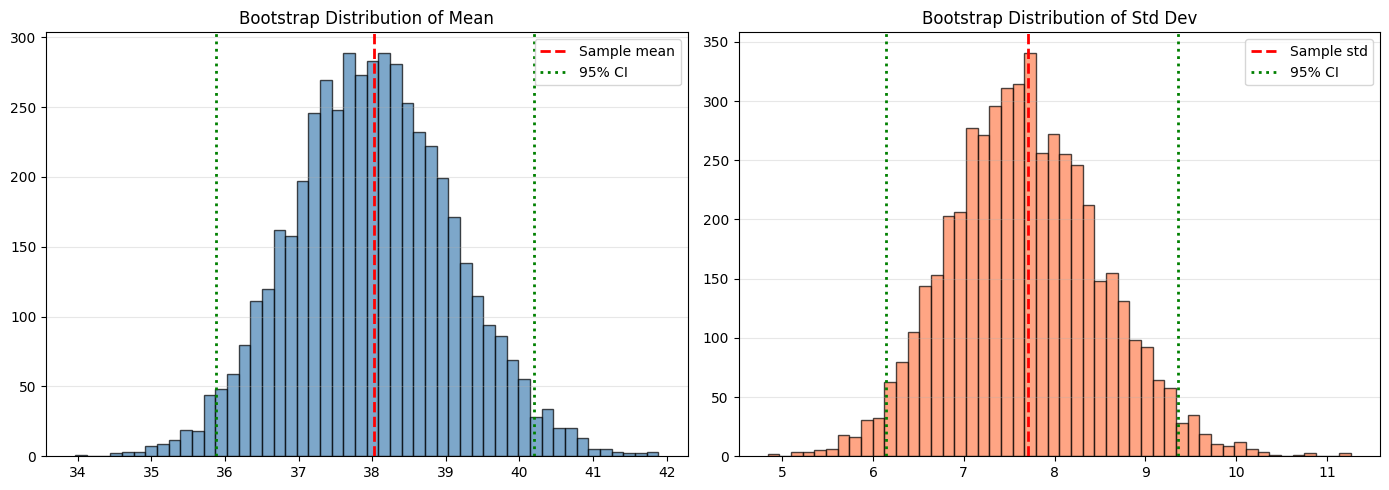

In [8]:
# Reproducible sample (same as your original setup)
rng = np.random.default_rng(202)
original_sample = GammaDistribution(2,20).GenerateRandomValues(50, 456)

# Fit parent distribution to original sample
parent = GammaDistribution()
parent.Estimate(original_sample, ParameterEstimationMethod.MethodOfMoments)

# Configure Numerics bootstrap
n_boot = 5000
bootstrap = BootstrapAnalysis(
    distribution=parent,
    estimationMethod=ParameterEstimationMethod.MethodOfMoments,
    sampleSize=len(original_sample),
    replications=n_boot,
    seed=456
)

# Bootstrap product moments: columns = [mean, std, skew, kurt]
boot_moments = bootstrap.ProductMoments()
boot_means = np.array([boot_moments[i, 0] for i in range(n_boot)], dtype=float)
boot_means_net = convert_to_dotnet_array(boot_means.tolist())
boot_stds = np.array([boot_moments[i, 1] for i in range(n_boot)], dtype=float)
boot_stds_net = convert_to_dotnet_array(boot_stds.tolist())

# 95% percentile CIs (using Numerics Statistics percentile)
ci_mean = Statistics.Percentile(boot_means_net, Array[float]([0.025, 0.975]))
ci_std = Statistics.Percentile(boot_stds_net, Array[float]([0.025, 0.975]))

boot_df = pd.DataFrame([
    {
        'Statistic': 'Mean',
        'Sample Estimate': float(np.mean(original_sample)),
        'Bootstrap Mean': float(np.mean(boot_means)),
        '95% CI Lower': float(ci_mean[0]),
        '95% CI Upper': float(ci_mean[1])
    },
    {
        'Statistic': 'Std Dev',
        'Sample Estimate': float(np.std(original_sample, ddof=1)),
        'Bootstrap Mean': float(np.mean(boot_stds)),
        '95% CI Lower': float(ci_std[0]),
        '95% CI Upper': float(ci_std[1])
    },
])

print(f'Bootstrap summary ({n_boot} replicates)')
display(boot_df)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bootstrap of the mean
axes[0].hist(boot_means, bins=50, alpha=0.7, color='steelblue', edgecolor='black')
axes[0].axvline(np.mean(original_sample), color='red', linestyle='--', linewidth=2, label='Sample mean')
axes[0].axvline(ci_mean[0], color='green', linestyle=':', linewidth=2, label='95% CI')
axes[0].axvline(ci_mean[1], color='green', linestyle=':', linewidth=2)
axes[0].set_title('Bootstrap Distribution of Mean')
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')

# Bootstrap of the std
axes[1].hist(boot_stds, bins=50, alpha=0.7, color='coral', edgecolor='black')
axes[1].axvline(np.std(original_sample, ddof=1), color='red', linestyle='--', linewidth=2, label='Sample std')
axes[1].axvline(ci_std[0], color='green', linestyle=':', linewidth=2, label='95% CI')
axes[1].axvline(ci_std[1], color='green', linestyle=':', linewidth=2)
axes[1].set_title('Bootstrap Distribution of Std Dev')
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 7. Outlier Detection: Multiple Grubbs-Beck Test
Detect multiple low outliers in hydrologic-style samples.

Multiple Grubbs-Beck summary


,Metric,Value
0,Sample size,50.000000
1,Mean,98.159548
2,Std Dev,21.844798
3,Low outliers detected (MGBT),2.000000


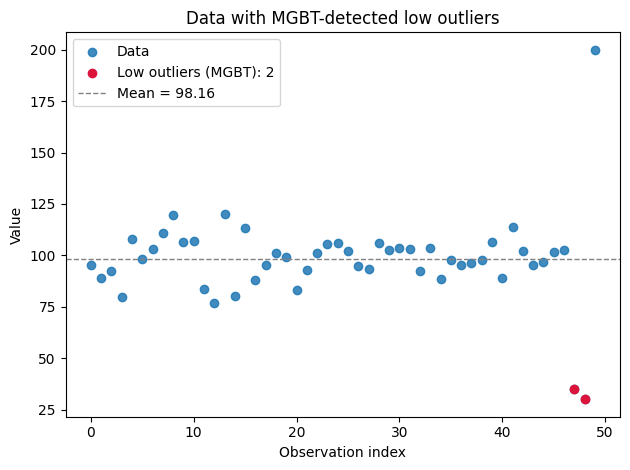

In [9]:
# Data with outliers
np.random.seed(303)
clean_data = np.asarray(Normal(100,10).GenerateRandomValues(47,789))
#np.random.normal(100, 10, 47)
outliers_vals = np.array([35, 30, 200])
data_with_outliers = np.concatenate([clean_data, outliers_vals])
data_net = convert_to_dotnet_array(data_with_outliers)

mean_val = Statistics.Mean(data_net)
std_val = Statistics.StandardDeviation(data_net)
grubbs = MultipleGrubbsBeckTest.Function(data_net)

outlier_df = pd.DataFrame({'Metric':['Sample size','Mean','Std Dev','Low outliers detected (MGBT)'],'Value':
                           [len(data_with_outliers),mean_val,std_val,grubbs]})
print('Multiple Grubbs-Beck summary')
display(outlier_df)


# Identify which points are low outliers for plotting
sorted_idx = np.argsort(data_with_outliers)
low_outlier_idx = sorted_idx[:grubbs] if grubbs > 0 else np.array([], dtype=int)

# Plot data with identified low outliers
x = np.arange(len(data_with_outliers))
plt.scatter(x, data_with_outliers, alpha=0.85, label="Data")
if grubbs > 0:
    plt.scatter(low_outlier_idx, data_with_outliers[low_outlier_idx], color="crimson",
                label=f"Low outliers (MGBT): {grubbs}")
plt.axhline(mean_val, color="gray", linestyle="--", linewidth=1, label=f"Mean = {mean_val:.2f}")
plt.title("Data with MGBT-detected low outliers")
plt.xlabel("Observation index")
plt.ylabel("Value")
plt.legend()
plt.tight_layout()
plt.show()

### Jenks Natural Breaks
Jenks natural breaks partitions data into classes that minimize within-class variance and maximize between-class variance.
This is useful for mapping, binning skewed data, and identifying natural groupings.


Jenks Natural Breaks summary


,Metric,Value
0,Classes (k),5
1,GVF,0.9632
2,Breaks,"[35.0, 89.10187406055996, 103.59864269665528, ..."


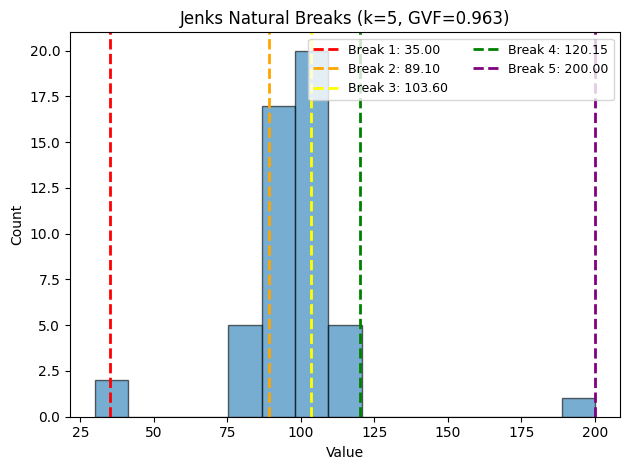

In [10]:
# Reuse data_with_outliers from the Grubbs-Beck section
data_net = convert_to_dotnet_array(data_with_outliers)

k = 5
jenks = JenksNaturalBreaks(data_net, k)
breaks = list(jenks.Breaks)
gvf = jenks.GoodnessOfVarianceFit

jenks_df = pd.DataFrame({'Metric':['Classes (k)','GVF','Breaks'],'Value':[k, gvf, breaks]})
print('Jenks Natural Breaks summary')
display(jenks_df)


# Histogram + Jenks break lines 
colors = ['red','orange','yellow','green','purple']
plt.hist(data_with_outliers, bins="auto", alpha=0.6, edgecolor="black")
for i, b in enumerate(breaks):
    plt.axvline(b, linestyle="--", linewidth=2, label=f"Break {i+1}: {b:.2f}", color = colors[i])
plt.title(f"Jenks Natural Breaks (k={k}, GVF={gvf:.3f})")
plt.xlabel("Value")
plt.ylabel("Count")
plt.legend(ncol=2, fontsize=9)
plt.tight_layout()
plt.show()


## 8. Data Transformations

The Box Cox and Yeo-Johnson tranformtions transform non-normal dependent varaibles into a normal shape.

Transformation summary table


,Transform,Sample Size,Mean,Std,Min,Max,Lambda,Round-Trip Error
0,Box-Cox (original),500,38.944335,132.921321,0.077764,1942.229448,0.020475,2.273737e-12
1,Box-Cox (transformed),500,2.380719,1.721469,-2.488445,8.190029,0.020475,2.273737e-12
2,Yeo-Johnson (original),500,2.527081,3.536851,-4.984451,18.998849,0.709817,3.552714e-15
3,Yeo-Johnson (transformed),500,1.645339,2.560638,-7.020563,10.403343,0.709817,3.552714e-15


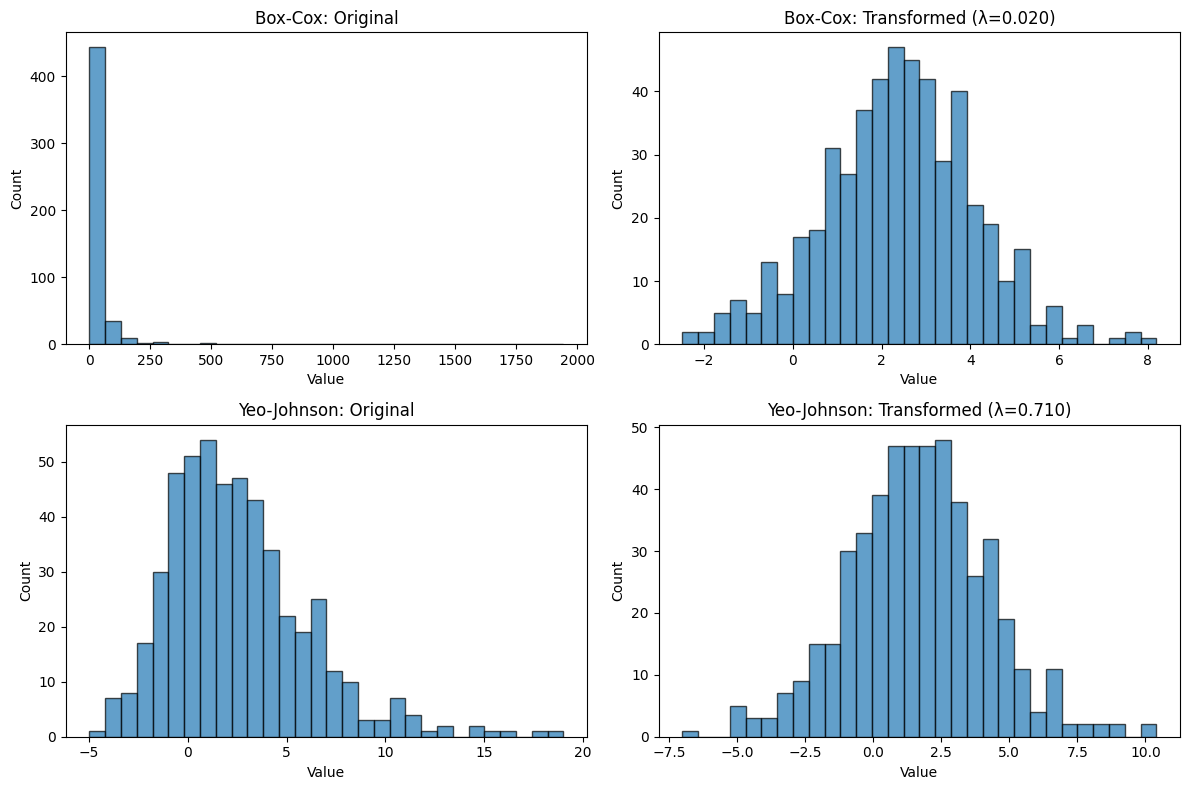

In [15]:
random.seed(42)
np.random.seed(42)

boxcox_data = LogNormal(1,0.75).GenerateRandomValues(500, 789) 
# np.random.lognormal(mean=1.0, sigma=0.75, size=500).tolist()
# boxcox_data_net = convert_to_dotnet_array(boxcox_data)
lambda_bc = BoxCox.FitLambda(boxcox_data)
bc_transformed = BoxCox.Transform(boxcox_data, lambda_bc)
bc_inverse = BoxCox.InverseTransform(bc_transformed, lambda_bc)
bc_error = np.max(np.abs(np.asarray(boxcox_data) - np.asarray(list(bc_inverse))))

yeojohnson_data =  np.array(Normal(0,2).GenerateRandomValues(500,456)) + np.array(Exponential(1, 1.5).GenerateRandomValues(500, 456))
#(np.random.normal(loc=0.0, scale=2.0, size=500) + np.random.exponential(scale=1.5, size=500) * np.random.choice([-1, 1], 500)).tolist()
yeojohnson_data_net = convert_to_dotnet_array(yeojohnson_data)
lambda_yj = YeoJohnson.FitLambda(yeojohnson_data_net)
yj_transformed = YeoJohnson.Transform(yeojohnson_data_net, lambda_yj)
yj_inverse = YeoJohnson.InverseTransform(yj_transformed, lambda_yj)
yj_error = np.max(np.abs(np.asarray(yeojohnson_data) - np.asarray(list(yj_inverse))))

transform_df = pd.DataFrame([
    {'Transform':'Box-Cox (original)','Sample Size':len(boxcox_data),'Mean':np.mean(boxcox_data),'Std':np.std(boxcox_data),'Min':np.min(boxcox_data),'Max':np.max(boxcox_data),'Lambda':lambda_bc,'Round-Trip Error':bc_error},
    {'Transform':'Box-Cox (transformed)','Sample Size':len(bc_transformed),'Mean':np.mean(bc_transformed),'Std':np.std(bc_transformed),'Min':np.min(bc_transformed),'Max':np.max(bc_transformed),'Lambda':lambda_bc,'Round-Trip Error':bc_error},
    {'Transform':'Yeo-Johnson (original)','Sample Size':len(yeojohnson_data),'Mean':np.mean(yeojohnson_data),'Std':np.std(yeojohnson_data),'Min':np.min(yeojohnson_data),'Max':np.max(yeojohnson_data),'Lambda':lambda_yj,'Round-Trip Error':yj_error},
    {'Transform':'Yeo-Johnson (transformed)','Sample Size':len(yj_transformed),'Mean':np.mean(yj_transformed),'Std':np.std(yj_transformed),'Min':np.min(yj_transformed),'Max':np.max(yj_transformed),'Lambda':lambda_yj,'Round-Trip Error':yj_error},
])
print('Transformation summary table')
display(transform_df)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Box-Cox hist
axes[0,0].hist(boxcox_data, bins=30, alpha=0.7, edgecolor='black')
axes[0,0].set_title("Box-Cox: Original")
axes[0,0].set_xlabel("Value"); axes[0,0].set_ylabel("Count")

axes[0,1].hist(bc_transformed, bins=30, alpha=0.7, edgecolor='black')
axes[0,1].set_title(f"Box-Cox: Transformed (λ={lambda_bc:.3f})")
axes[0,1].set_xlabel("Value"); axes[0,1].set_ylabel("Count")

# Yeo-Johnson hist
axes[1,0].hist(yeojohnson_data, bins=30, alpha=0.7, edgecolor='black')
axes[1,0].set_title("Yeo-Johnson: Original")
axes[1,0].set_xlabel("Value"); axes[1,0].set_ylabel("Count")

axes[1,1].hist(yj_transformed, bins=30, alpha=0.7, edgecolor='black')
axes[1,1].set_title(f"Yeo-Johnson: Transformed (λ={lambda_yj:.3f})")
axes[1,1].set_xlabel("Value"); axes[1,1].set_ylabel("Count")

plt.tight_layout()
plt.show()


## Summary

You've learned:

✓ Descriptive statistics and data exploration  
✓ Correlation analysis (Pearson, Spearman, Kendall)     
✓ Parametric testing (t-test)       
✓ Non-parametric testing (Mann-Whitney)     
✓ Goodness-of-fit testing (KS test)     
✓ Bootstrap confidence intervals        
✓ Outlier detection (Grubbs' test)      
✓ Data transformations (Box-Cox, Yeo-Johnson)       

## Key Takeaways

1. **Start with visualization** - Always plot your data first
2. **Check assumptions** - Use Q-Q plots and normality tests
3. **Choose appropriate tests** - Parametric vs non-parametric
4. **Bootstrap for uncertainty** - Works without strong assumptions
5. **Handle outliers carefully** - Investigate before removing

## Statistical Test Selection Guide

| Situation | Test to Use |
|-----------|-------------|
| Compare 2 means (normal data) | t-test |
| Compare 2 means (non-normal) | Mann-Whitney U |
| Test for normality | KS test, Q-Q plot |
| Outlier detection | Grubbs' test |
| Confidence intervals | Bootstrap |
| Normalize skewed data | Box-Cox transform |
| Mixed signs data | Yeo-Johnson transform |

## Next Steps

- **08_time_series.ipynb** - Temporal data analysis
- **02_distribution_fitting.ipynb** - Fit distributions to data

## Exercise

1. Generate two samples from different distributions
2. Perform both t-test and Mann-Whitney test
3. Create bootstrap confidence intervals
4. Which test is more appropriate? Why?